# Mean Listed Price by Genre

The Steam merchandising team wants to compare mean listed prices across eight major game genres and identify which genre has the highest average listed price.

## Load and prepare the data

Load the Steam dataset and prepare the listed price field for the genre comparison.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd


STEAM_PATH = "../../data/steam/steam.csv"

TARGET_GENRES = [
    "Action",
    "Adventure",
    "Casual",
    "Indie",
    "RPG",
    "Strategy",
    "Simulation",
    "Sports",
]

steam = pd.read_csv(STEAM_PATH)

steam["price"] = pd.to_numeric(
    steam["price"],
    errors="coerce",
)

print(
    "Dataset loaded:",
    f"{len(steam):,} games",
)

steam.head()

Dataset loaded: 27,075 games


,appid,name,release_date,english,developer,publisher,platforms,required_age,categories,genres,steamspy_tags,achievements,positive_ratings,negative_ratings,average_playtime,median_playtime,owners,price
0,10,Counter-Strike,2000-11-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,Action;FPS;Multiplayer,0,124534,3339,17612,317,10000000-20000000,7.19
1,20,Team Fortress Classic,1999-04-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,Action;FPS;Multiplayer,0,3318,633,277,62,5000000-10000000,3.99
2,30,Day of Defeat,2003-05-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Valve Anti-Cheat enabled,Action,FPS;World War II;Multiplayer,0,3416,398,187,34,5000000-10000000,3.99
3,40,Deathmatch Classic,2001-06-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,Action;FPS;Multiplayer,0,1273,267,258,184,5000000-10000000,3.99
4,50,Half-Life: Opposing Force,1999-11-01,1,Gearbox Software,Valve,windows;mac;linux,0,Single-player;Multi-player;Valve Anti-Cheat en...,Action,FPS;Action;Sci-fi,0,5250,288,624,415,5000000-10000000,3.99


## Inspect and prepare genre assignments

Inspect how genres are represented before selecting the requested categories. Games can contain multiple genre labels, so split these assignments and create one game–genre record for each label.

In [2]:
genre_counts_per_game = (
    steam["genres"]
    .fillna("")
    .str.split(";")
    .str.len()
)

multi_genre_count = (
    genre_counts_per_game > 1
).sum()

print(
    "Games with multiple genre labels:",
    f"{multi_genre_count:,}",
)

print(
    "Share of games with multiple genres:",
    f"{multi_genre_count / len(steam):.1%}",
)


genre_data = (
    steam
    .assign(
        genre=(
            steam["genres"]
            .fillna("")
            .str.split(";")
        )
    )
    .explode("genre")
)

genre_data["genre"] = (
    genre_data["genre"]
    .str.strip()
)

genre_data = genre_data[
    genre_data["genre"].isin(TARGET_GENRES)
].copy()

print(
    "\nGames represented in target genres:",
    f"{genre_data['appid'].nunique():,}",
)

print(
    "Game–genre records:",
    f"{len(genre_data):,}",
)

Games with multiple genre labels: 23,032
Share of games with multiple genres: 85.1%

Games represented in target genres: 26,728
Game–genre records: 67,640


## Calculate genre-level price statistics

Calculate the number of distinct games, mean listed price, and median listed price for each requested genre using the expanded genre assignments.

In [3]:
genre_summary = (
    genre_data
    .groupby("genre")
    .agg(
        game_count=("appid", "nunique"),
        mean_price=("price", "mean"),
        median_price=("price", "median"),
    )
    .reindex(TARGET_GENRES)
    .reset_index()
)

print(
    genre_summary
    .round(
        {
            "mean_price": 2,
            "median_price": 2,
        }
    )
    .to_string(index=False)
)

     genre  game_count  mean_price  median_price
    Action       11903        6.14          3.99
 Adventure       10032        6.12          4.79
    Casual       10210        4.11          2.89
     Indie       19421        5.05          3.99
       RPG        4311        6.94          4.99
  Strategy        5247        6.94          4.99
Simulation        5194        7.21          4.99
    Sports        1322        7.88          5.19


## Rank genres by mean price

Rank the eight genres by mean listed price and identify the genre with the highest average.

In [4]:
genre_ranking = (
    genre_summary
    .sort_values(
        "mean_price",
        ascending=False,
    )
    .reset_index(drop=True)
)

genre_ranking.index += 1
genre_ranking.index.name = "rank"


display_summary = genre_ranking.copy()

display_summary["mean_price"] = (
    display_summary["mean_price"]
    .map(lambda x: f"${x:.2f}")
)

display_summary["median_price"] = (
    display_summary["median_price"]
    .map(lambda x: f"${x:.2f}")
)


print("Genre ranking by mean price:")

print(
    display_summary[
        [
            "genre",
            "mean_price",
        ]
    ].to_string()
)


highest = genre_ranking.iloc[0]

print("\nFinal result:")

print(
    "Genre with the highest average price:",
    highest["genre"],
)

print(
    "Highest average price:",
    f"${highest['mean_price']:.2f}",
)

Genre ranking by mean price:
           genre mean_price
rank                       
1         Sports      $7.88
2     Simulation      $7.21
3       Strategy      $6.94
4            RPG      $6.94
5         Action      $6.14
6      Adventure      $6.12
7          Indie      $5.05
8         Casual      $4.11

Final result:
Genre with the highest average price: Sports
Highest average price: $7.88


## Visualize genre coverage

Compare the number of games represented in each requested genre after accounting for multi-genre assignments.

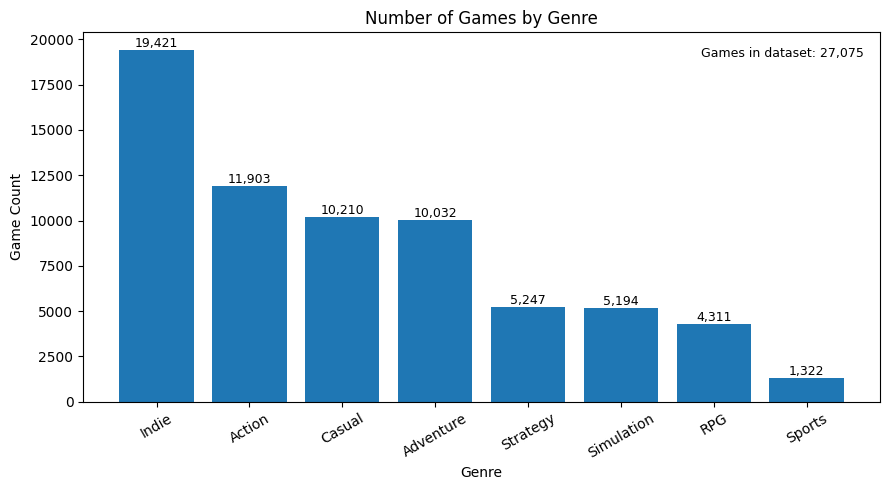

In [5]:
plot_data = (
    genre_summary
    .sort_values(
        "game_count",
        ascending=False,
    )
)

fig, ax = plt.subplots(
    figsize=(9, 5)
)

bars = ax.bar(
    plot_data["genre"],
    plot_data["game_count"],
)

ax.set_title(
    "Number of Games by Genre"
)

ax.set_xlabel(
    "Genre"
)

ax.set_ylabel(
    "Game Count"
)

ax.tick_params(
    axis="x",
    rotation=30,
)

for bar in bars:
    height = bar.get_height()

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height):,}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

ax.text(
    0.98,
    0.96,
    (
        f"Games in dataset: {len(steam):,}\n"
    ),
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=9,
)

plt.tight_layout()
plt.show()

## Conclusion

Sports has the highest mean listed price among the eight genres analyzed, with an average price of approximately **$7.88**.

The comparison accounts for games with multiple genre assignments by including each game in every requested genre to which it belongs.